# Customer Churn Prediction using Logistic Regression and Neural Networks

## Introduction

Customer churn prediction is a classification problem in machine learning where the objective is to identify customers who are likely to discontinue a company's service.

Predicting churn helps organizations:

- Improve customer retention
- Reduce revenue loss
- Increase customer satisfaction
- Develop targeted marketing strategies

In this project, two machine learning models are implemented and compared:

1. Logistic Regression
2. Artificial Neural Network (MLP Classifier)

The complete workflow includes data preprocessing, exploratory data analysis, model training, evaluation, and visualization.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use('default')
sns.set_theme()

# Load Dataset

In [2]:
df = pd.read_csv("../Dataset/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
#Dataset Shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 14


In [4]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
#Statistical Suammary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
#Missing Values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Exploratory Data Analysis (EDA)

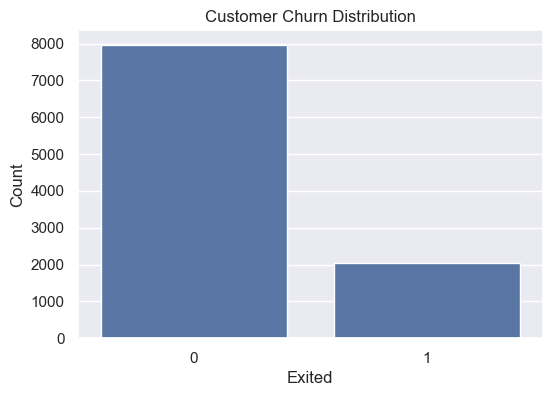

In [7]:
#target Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

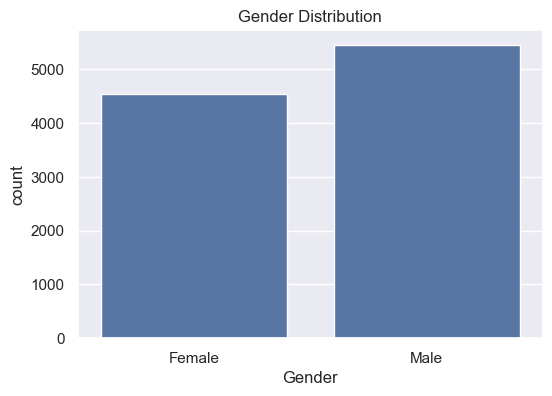

In [8]:
#Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")
plt.show()

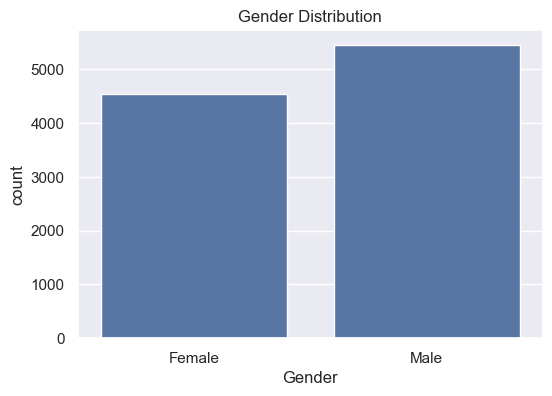

In [9]:
#Geography Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")
plt.show()

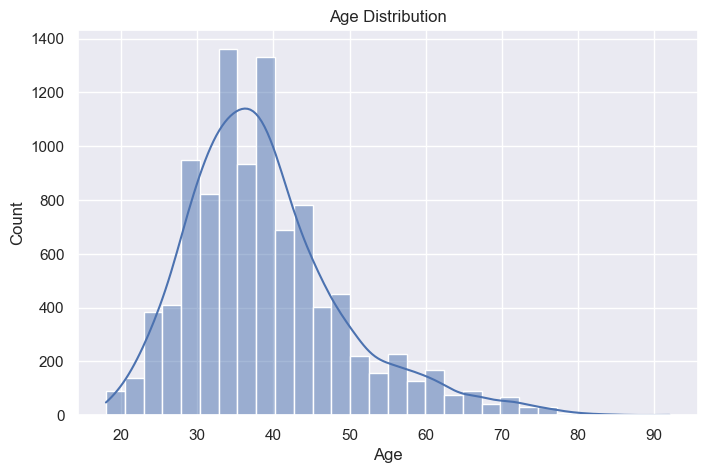

In [10]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

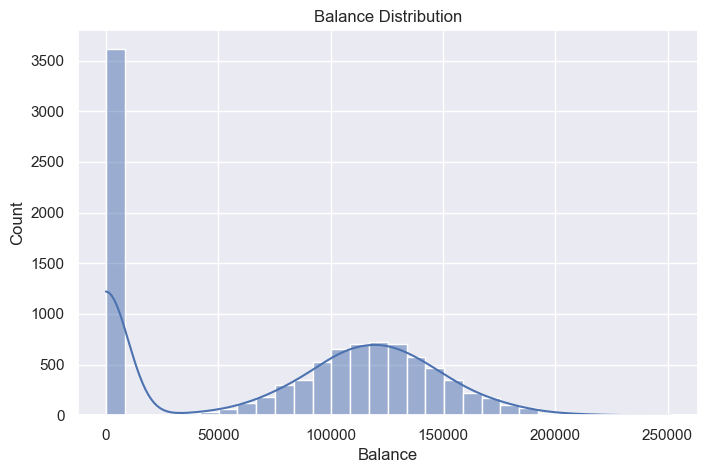

In [11]:
#Balance Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Balance'],
    bins=30,
    kde=True
)

plt.title("Balance Distribution")

plt.show()

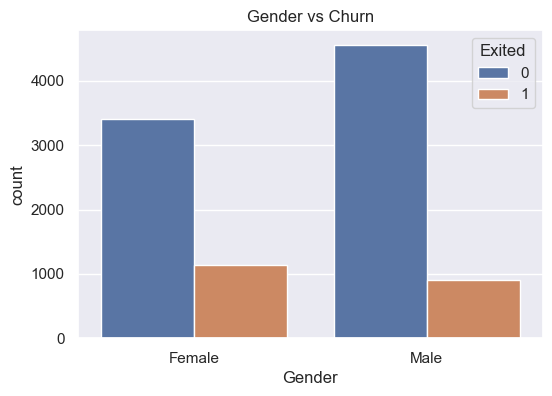

In [12]:
#Churn by Gender 
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title("Gender vs Churn")

plt.show()

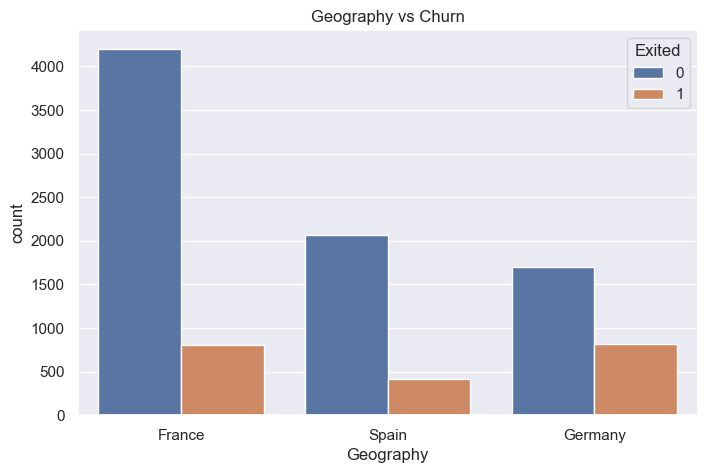

In [13]:
#Churn by Geography
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography vs Churn")

plt.show()

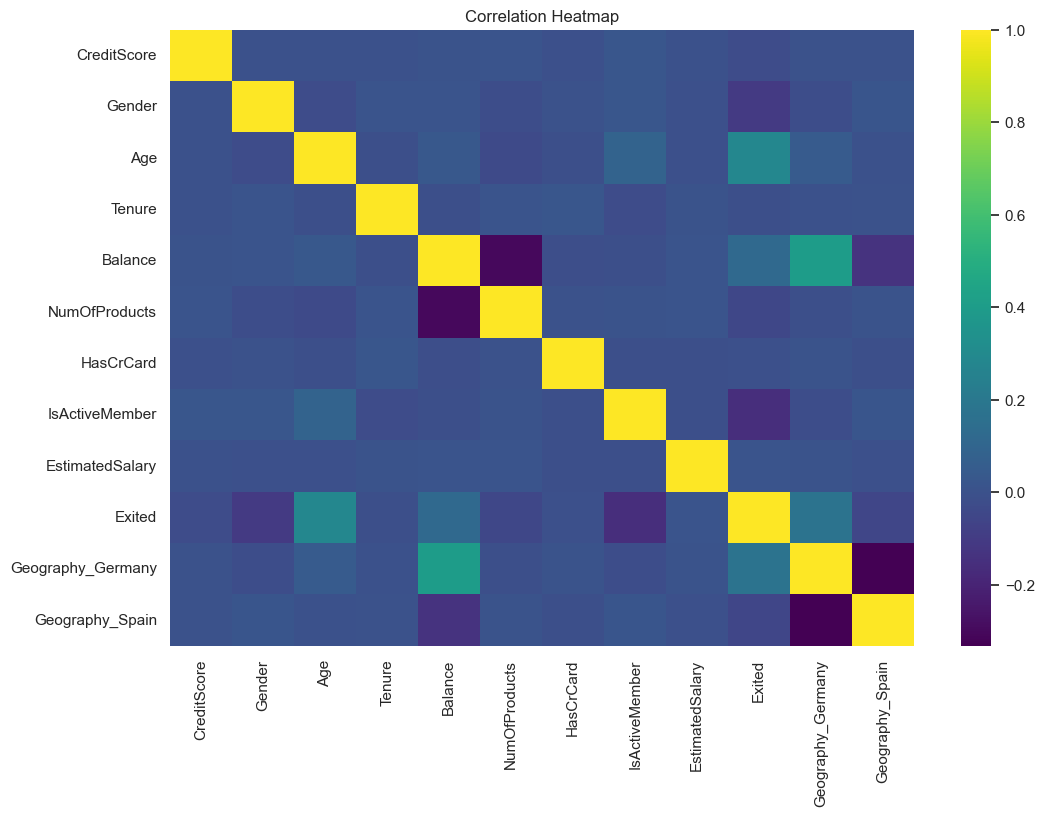

In [14]:
#Correlation heatmap
temp = df.copy()

temp['Gender'] = LabelEncoder().fit_transform(
    temp['Gender']
)

temp = pd.get_dummies(
    temp,
    columns=['Geography'],
    drop_first=True
)

temp = temp.drop(
    ['RowNumber','CustomerId','Surname'],
    axis=1
)

plt.figure(figsize=(12,8))

sns.heatmap(
    temp.corr(),
    cmap='viridis'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/heatmap.png",
    bbox_inches='tight'
)

plt.show()

# Data Preprocessing

In [15]:
#Remove Unnecessary Columns
df = df.drop(
    ['RowNumber','CustomerId','Surname'],
    axis=1,
    errors='ignore'
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
#Encode Gender
le = LabelEncoder()

df['Gender'] = le.fit_transform(
    df['Gender']
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [17]:
#One Hot Encoding
df = pd.get_dummies(
    df,
    columns=['Geography'],
    drop_first=True
)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [18]:
#Features and Targets 
X = df.drop(
    'Exited',
    axis=1
)

y = df['Exited']

In [19]:
#Train Test 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# Feature Engineering

In [21]:
#Feature Matrix Information
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (8000, 11)
Testing Samples : (2000, 11)


In [22]:
#class Distribution
pd.Series(y_train).value_counts()

Exited
0    6370
1    1630
Name: count, dtype: int64

In [23]:
#Target Percentage 
(pd.Series(y_train).value_counts(normalize=True) * 100)

Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

The model estimates the probability that a customer belongs to a particular class (Churn or No Churn).

In [24]:
#Train Model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [25]:
#prediction using Logistic Regression Model
lr_pred = lr_model.predict(X_test)

lr_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [26]:
#accuracy Score
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print(
    f"Accuracy : {lr_accuracy:.4f}"
)

Accuracy : 0.8080


In [27]:
#Classification Report
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



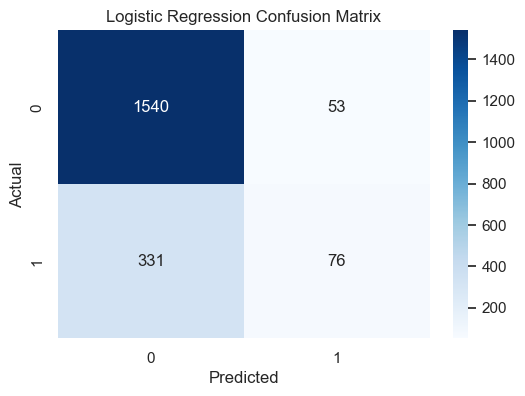

In [28]:
#confusion Matrix
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Neural Network Model (MLP Classifier)

Artificial Neural Networks can learn complex nonlinear relationships from data.

A Multi-Layer Perceptron (MLP) is used in this project.

In [ ]:
#Train Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

nn_model.fit(
    X_train,
    y_train
)

print("Neural Network Trained Successfully")

In [ ]:
#prediction
nn_pred = nn_model.predict(
    X_test
)

nn_pred[:10]

In [ ]:
#Accuracy Score 
nn_accuracy = accuracy_score(
    y_test,
    nn_pred
)

print(
    f"Accuracy : {nn_accuracy:.4f}"
)

In [ ]:
#Classification Report 
print(
    classification_report(
        y_test,
        nn_pred
    )
)

In [ ]:
#Confusion Matrix
nn_cm = confusion_matrix(
    y_test,
    nn_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    nn_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "Neural Network Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Evaluation

The performance of both models is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [ ]:
#Performance Table
comparison = pd.DataFrame({
    'Model':
    [
        'Logistic Regression',
        'Neural Network'
    ],

    'Accuracy':
    [
        lr_accuracy,
        nn_accuracy
    ]
})

comparison

# ROC Curve Analysis

Receiver Operating Characteristic (ROC) Curve evaluates the classification capability of a model at different threshold values.

Higher AUC indicates better model performance.

In [ ]:
#Prediction Possibilities 
lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

nn_prob = nn_model.predict_proba(
    X_test
)[:,1]

In [ ]:
#ROC Calculation
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_prob
)

nn_fpr, nn_tpr, _ = roc_curve(
    y_test,
    nn_prob
)

lr_auc = auc(
    lr_fpr,
    lr_tpr
)

nn_auc = auc(
    nn_fpr,
    nn_tpr
)

In [ ]:
#Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression AUC = {lr_auc:.3f}'
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f'Neural Network AUC = {nn_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/roc_curve.png",
    bbox_inches='tight'
)

plt.show()

# Feature Importance Analysis

Feature importance helps identify which customer attributes influence churn prediction the most.

In [ ]:
#Extract Importance
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    np.abs(
        lr_model.coef_[0]
    )

})

In [ ]:
#Sort Features
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

In [ ]:
#Plot Features
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance Analysis"
)

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    bbox_inches='tight'
)

plt.show()

# Model Comparison

After training both classification models, a comparative analysis was performed to evaluate their predictive performance.

The following metrics were considered:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

This comparison helps determine which model performs better for customer churn prediction.

In [ ]:
#Accuracy Comaprision Chart
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.savefig(
    "../images/model_comparison.png",
    bbox_inches='tight'
)

plt.show()

In [ ]:
#Comparision Table 
comparison.sort_values(
    by='Accuracy',
    ascending=False
)

# Conclusion

In this project, customer churn prediction was performed using two machine learning models:

1. Logistic Regression
2. Neural Network (MLP Classifier)

Major tasks completed:

- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis
- Correlation Analysis
- Model Training
- Model Evaluation
- ROC Curve Analysis
- Feature Importance Analysis
- Model Comparison

The results demonstrate how machine learning can be used to identify customers at risk of leaving a business and assist organizations in improving customer retention strategies.

Future improvements may include:

- Random Forest
- XGBoost
- LightGBM
- Deep Learning Models
- Hyperparameter Optimization
- Deployment using Flask or Streamlit